In [1]:
import numpy as np;
import time
import scipy.io
import sys
import math

def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

In [197]:
def my_print(name, val):
    print(f'{name}: {val}')
    return

# test=np.array([10])
# my_print('test', test)

In [3]:
def list_str_to_float(arr):
    out = []
    for i in arr:
        out+=[float(i)]
    return out


In [161]:
def append_list_to_np_arr(lst, np_arr):
    bs_lst=[]
    for i in range(len(lst)):
#         bs_lst+= [[lst[i], lst[i]]]
        bs_lst+= [[lst[i]]]
    
    np_lst=np.array([bs_lst])
#     my_print('np_lst.shape', np_lst.shape)

    if np_arr.shape[0] == 0:
        np_arr = np_lst 
    else:
        np_arr = np.concatenate((np_arr, np_lst), axis=0) 
#     my_print('np_lst.shape', np_arr.shape)
    return np_arr

def append_bplist_to_np_arr(lst, np_arr):
    bp_lst = []
    for i in range(1, len(lst)):
        bp_lst+= [[lst[i-1], lst[i]]]
    np_bp=np.array([bp_lst])
    
#     my_print('np_bp', np_bp.shape)
#     my_print('np_arr', np_arr.shape)
    if np_arr.shape[0] == 0:
        np_arr = np_bp
    else:
        np_arr = np.concatenate((np_arr, np_bp), axis=0) 
#     print(np_arr.shape)
    return np_arr

# lst=list(range(10))
# np_arr = np.array([])
# np_arr = append_bplist_to_np_arr(lst, np_arr)
# append_bplist_to_np_arr(lst, np_arr)

# First turn shape vals into .mat and treat bs shapes as 2 features

In [203]:
# make a 4 sequence fake input to network that is 4 X 147 X 39 
# 2 in enriched and 2 in depleted
def makeSingleShapeArr(seq_file, total_sections, section):
#     print(">>>>>>>>> In making makeSingleShapeArr ")
    np_all_shape_arr = np.array([])
    
    Seqs = readInputAsArray(seq_file)
    seq_count=1
    bp_shape=False
    total_lines = 0;
    total_sections = int(total_sections);
    section = int(section);
    
    for line in Seqs:
        l = line.split()
        if l[1] != '3': # Only consider flanking region of size 3
            continue;
        total_lines += 1;
        
    print(f"Total # of regions is: {total_sections}\n");
    print(f"Current regions is: {section}\n");
    print(f"Total # of lines is: {total_lines}\n");
    section_length = math.floor(total_lines / total_sections);
    start_line = (section-1) * section_length;
    end_line = section * section_length-1;

    if (end_line > total_lines):
        end_line = total_lines-1;

    line_count = 0;
    for line in Seqs:
        l = line.split()
        if l[1] != '3': # Only consider flanking region of size 3
            continue;
        if(line_count < start_line):
            line_count += 1;
            continue;
        if(line_count > end_line):
            break;
        line_count += 1;
        
        curr_seq_shape_list = list_str_to_float(l[2:]) # get the shape values only
        if len(l[0]) > len(curr_seq_shape_list):
#             print("base step parameter")
            bp_shape = False
        else:
#             print("base pair parameter")
            bp_shape = True
        
        ## 1. for base pair shapes, there are 147 vals for each seq 
        if bp_shape: 
            if len(curr_seq_shape_list) < 147:
                while len(curr_seq_shape_list) < 147: # if the sequence is shorter than 147
                    curr_seq_shape_list+=[0]
                    
                np_all_shape_arr = append_bplist_to_np_arr(curr_seq_shape_list, np_all_shape_arr)
            else:
                start = 0
                 # is a base pair shape, each 147bp seq has 147 shape vals, we use 147-2+1
                while (start < len(curr_seq_shape_list)-146):
                    curr_start = start;
                    curr_end = 146 + start;
                    sub_seq_shape_list = curr_seq_shape_list[curr_start: curr_end+1];
                    start+=1
                    np_all_shape_arr = append_bplist_to_np_arr(sub_seq_shape_list, np_all_shape_arr)

        ## 2. for base step shapes, there are 146 vals for each seq 
        else:
            if len(curr_seq_shape_list) < 146:
                while len(curr_seq_shape_list) < 146: # if the sequence is shorter than 146
                    curr_seq_shape_list+=[0]
                    
                np_all_shape_arr = append_list_to_np_arr(curr_seq_shape_list, np_all_shape_arr)
            else:
#                 print('>>>>>> Found longer sequences')
                start = 0
                # is a base step shape, each 147bp seq has 146 shape vals, we use 146-2+1
                while (start < len(curr_seq_shape_list)-145):
                    curr_start = start;
                    curr_end = 145 + start;
                    sub_seq_shape_list = curr_seq_shape_list[curr_start: curr_end+1];
                    start+=1
                    np_all_shape_arr = append_list_to_np_arr(sub_seq_shape_list, np_all_shape_arr)
#         my_print('np_all_shape_arr', np_all_shape_arr.shape)
        seq_count+=1
#     my_print('np_all_shape_arr.shape', np_all_shape_arr.shape)
    return np_all_shape_arr;


###### Now merge the single shape arrs to a whole np array
def concatAllShapeArr(seq_file, All_Shapes, total_sections, section):
    np_shape_E = np.array([]) # enriched seqs output

    for i in range(len(All_Shapes)):
        my_print('\ncurr shape is ', All_Shapes[i])
        np_all_shape_arr = makeSingleShapeArr(seq_file + All_Shapes[i] + '.txt', total_sections, section)
        if np_shape_E.shape[0] == 0:
            np_shape_E = np_all_shape_arr
        else:
            ## merge exp1: consider the base step as separate features
            np_shape_E = np.concatenate([np_shape_E, np_all_shape_arr], axis=2) #(218, 146, 3)
            
#             np_shape_E = np.stack([np_shape_E, np_all_shape_arr], axis=2) #(218, 146, 2, 2)
    return np_shape_E

################################################## Main ##################################################
seq_file='/home/yibei/Downloads/yibei_predictions/'
All_Shapes=['Buckle-FL', 'Buckle', 'EP', 'HelT-FL', 'HelT', 'MGW-FL', 'MGW', 
                'Opening-FL', 'Opening', 'ProT-FL', 'ProT', 'Rise-FL', 'Rise', 'Roll-FL',
                'Roll', 'Shear-FL', 'Shear', 'Shift-FL', 'Shift', 'Slide-FL', 'Slide', 
                'Stagger-FL', 'Stagger', 'Stretch-FL', 'Stretch', 'Tilt-FL', 'Tilt']

# tb_file='/home/yibei/Projects/nucleosome_occupancy/pentamer_table.txt'
# seq_file='/Users/yibeijia/Downloads/yibei_predictions/'
np_shape_E = np.array([])
np_shape_D = np.array([])

total_sections=1000
section = 1
# All_Shapes=['Stretch']
print("Getting Enriched Seqs")
np_shape_E = concatAllShapeArr(seq_file+'enriched_', All_Shapes, total_sections, section) # depleted seqs output

# All_Shapes=['Roll', 'Stretch']
print("Getting Depleted Seqs")
np_shape_D = concatAllShapeArr(seq_file+'depleted_', All_Shapes, total_sections, section) # enriched seqs output

my_print('np_shape_E', np_shape_E.shape) # (NumSeq, 147, 39)
my_print('np_shape_D', np_shape_D.shape) # (NumSeq, 147, 39)

data = {"EnrichedData": np_shape_E, "DepletedData": np_shape_D};
# mat_filename = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/sampleSeqs.mat';
mat_filename = '/home/yibei/Projects/data/train_test_data/ShapeDNNSeqs_' + str(section) + '.mat';
scipy.io.savemat(mat_filename, data,  do_compression=True);

Getting Enriched Seqs

curr shape is : Buckle-FL
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : Buckle
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : EP
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : HelT-FL
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : HelT
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : MGW-FL
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : MGW
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : Opening-FL
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : Opening
Total # of regions is: 1000

Current regions is: 1

Total # of lines is: 18450


curr shape is : ProT-FL
Total # of region

## Treat base step parameter as 2 features because they are not correlated at all

>>>>>>>>> In making makeSingleShapeArr 

curr shape is : Roll


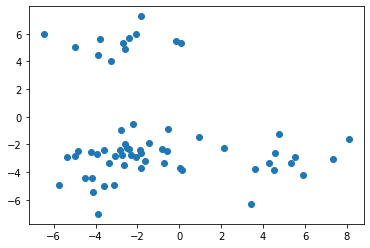

In [190]:
print(">>>>>>>>> In making makeSingleShapeArr ")
np_all_shape_arr = np.array([])
seq_file='/home/yibei/Downloads/yibei_predictions/'

All_Shapes=['Roll']
x = []
y = []
for i in range(len(All_Shapes)):
    my_print('\ncurr shape is ', All_Shapes[i])
    Seqs = readInputAsArray(seq_file + 'test_depleted_' +All_Shapes[i] + '.txt')
    seq_count=1
    bp_shape=False

    for line in Seqs:
        l = line.split()
        if l[1] != '3': # Only consider flanking region of size 3
            continue;
        curr_seq_shape_list = list_str_to_float(l[2:]) # get the shape values only
        x=curr_seq_shape_list[::2]
#         print(curr_seq_shape_list)
#         print('x')
#         print(x)
        y=curr_seq_shape_list[1::2]
#         print('y')
#         print(y)
import matplotlib.pyplot as plt

plt.scatter(x,y)
plt.show()


# Now split data to Train and Test

In [1]:
# import math
# import pandas as pd
# import numpy as np
# import scipy.io as sio
# from os.path import dirname, join as pjoin
# import os.path
# import time
# import random

# tic = time.perf_counter()
# Edata_list = np.array([])
# Ddata_list = np.array([])
# Ndata_list = np.array([])
# N=1
# print(f"N is: {N}")
# # for i in range(1, 51):
# for i in range(10, 20):
#     print(i)
#     # fname = '/scratch2/yibeijia/data/nucleosome_occupancy_' + str(i) + '.mat'
#     # fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/nucleosome_occupancy_' + str(i) + '.mat'
# #     fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/wormSeqs_'+str(i)+'.mat'
#     fname = '/home/yibei/Projects/data/train_test_data/ShapeDNNSeqs_'+str(i)+'.mat'
#     if os.path.isfile(fname):
#         mat_fname = pjoin(fname)
#         mat_contents = sio.loadmat(mat_fname)
        
#         edata=mat_contents['EnrichedData']
# #         ddata=np.array([])# when the seqs are all enriched
#         ndata=np.array([])
#         ddata=mat_contents['DepletedData']
# #         ndata=mat_contents['NeutralData']

#         if edata.size >0:
#             if Edata_list.size == 0:
#                 print("Init Elist")
#                 Edata_list=edata[::N]
#             else:
#                 Edata_list = np.concatenate((Edata_list, edata[::N]), axis=0)
          
#         if ddata.size >0:
#             if Ddata_list.size == 0:
#                 print("Init Dlist")
#                 Ddata_list = ddata[::N];
#             else:

#                 Ddata_list = np.concatenate((Ddata_list, ddata[::N]), axis=0)

#         if ndata.size >0:
#             if Ndata_list.size == 0:
#                 print("Init Nlist")
#                 Ndata_list = ndata[::N];
#             else:

#                 Ndata_list = np.concatenate((Ndata_list, ndata[::N]), axis=0)
#     # else:
#     #     for j in range(0, 20): See SplitData.py


# print("Enriched list size")
# print(Edata_list.shape)    
# print("Depleted list size")
# print(Ddata_list.shape)  
# print("Neutral list size")
# print(Ndata_list.shape)    
# toc=time.perf_counter()
# print(f"Create master list took {toc - tic:0.4f} seconds")

# D_empty = True
# E_empty = True
# Ddata_labels=np.array([])
# Edata_labels=np.array([])
# data_labels=np.array([])
# data_list =np.empty((1, 1, 1))
# start = True
# if Ddata_list.size >0:
#     if (Ddata_list.shape[0] > 0):
#         print("D non empty")
#         D_empty =False
#         Ddata_labels = np.zeros(Ddata_list.shape[0])

# if Edata_list.size >0:
#     if (Edata_list.shape[0] > 0):
#         if start:
#             # print(Edata_list[0])
#             start=False
#         print("E non empty")
#         E_empty =False
#         Edata_labels = np.ones(Edata_list.shape[0])

# if (E_empty==False and D_empty==False):
#     print("both non empty")
#     data_labels =  np.concatenate((Edata_labels, Ddata_labels), axis=0)
#     data_list = np.concatenate((Edata_list, Ddata_list), axis=0)
# elif (E_empty and D_empty==False):
#     print("D non empty, E is empty")
#     data_labels =  Ddata_labels
#     data_list=Ddata_list
# elif (E_empty==False and D_empty):
#     print("E non empty, D is empty")
#     data_labels = Edata_labels
#     data_list=Edata_list

# # print(data_list[2][0:4])
# ## Decide to not mix neutral data in the dataset because training is not with the neutral data.

# from sklearn.model_selection import train_test_split
# Train_data, Test_data, Train_labels, Test_labels = train_test_split(data_list, data_labels, test_size=0.50, random_state=42)
# print(f" All Test data shape is: {Test_data.shape}")
# print(f" All Test label shape is: {Test_labels.shape}")
# print(f" All Train data shape is: {Train_data.shape}")
# print(f" All Train label shape is: {Train_labels.shape}")

# Data = {"Test_data" : np.array(Test_data), "Test_labels" : Test_labels}   
# sio.savemat('/home/yibei/Projects/data/train_test_data/ShapeDNNSeqs_Test.mat',Data, do_compression=True)
# print('Wrote test data to mat ')

# Data = {"Train_data" : np.array(Train_data), "Train_labels" : Train_labels}   
# sio.savemat('/home/yibei/Projects/data/train_test_data/ShapeDNNSeqs_Train.mat',Data, do_compression=True)
# print('Wrote train data to mat ')

# # sio.savemat('/scratch2/yibeijia/data/train_test_data/Test_data.mat',Data, do_compression=True)
# # sio.savemat('/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/wormTest.mat', Data
# # sio.savemat('/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/wormTest.mat', Data, do_compression=True)
# # print(Data)
# # sio.savemat('/scratch2/yibeijia/data/train_test_data/Test_data.mat',Data, do_compression=True)


N is: 1
10
Init Elist
Init Dlist
11
12
13
14
15
16
17
18
19
Enriched list size
(164334, 146, 42)
Depleted list size
(251126, 146, 42)
Neutral list size
(0,)
Create master list took 59.1987 seconds
D non empty
E non empty
both non empty
 All Test data shape is: (207730, 146, 42)
 All Test label shape is: (207730,)
 All Train data shape is: (207730, 146, 42)
 All Train label shape is: (207730,)


MatWriteError: Matrix too large to save with Matlab 5 format